## MLP using Sklearn

In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import numpy

In [2]:
# fix random seed for reproducibility
seed = 7
numpy.random.seed(seed)

In [3]:
# load pima indians dataset
dataset = numpy.loadtxt("pima-indians-diabetes.csv", delimiter=",")
# split into input (X) and output (Y) variables
X = dataset[:,0:8]
y = dataset[:,8]

In [4]:
# train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=1/3,random_state=42, stratify=y)

In [5]:
#Normalization

scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
from sklearn.neural_network import MLPClassifier
mlp = MLPClassifier(hidden_layer_sizes=(10,10),max_iter=1000, verbose=2)
mlp.fit(X_train, y_train)

Iteration 1, loss = 0.97322078
Iteration 2, loss = 0.95988981
Iteration 3, loss = 0.94696938
Iteration 4, loss = 0.93513825
Iteration 5, loss = 0.92364982
Iteration 6, loss = 0.91253170
Iteration 7, loss = 0.90252676
Iteration 8, loss = 0.89203360
Iteration 9, loss = 0.88301304
Iteration 10, loss = 0.87440040
Iteration 11, loss = 0.86560356
Iteration 12, loss = 0.85744149
Iteration 13, loss = 0.84999216
Iteration 14, loss = 0.84251866
Iteration 15, loss = 0.83473714
Iteration 16, loss = 0.82785462
Iteration 17, loss = 0.82033614
Iteration 18, loss = 0.81305501
Iteration 19, loss = 0.80620462
Iteration 20, loss = 0.79849013
Iteration 21, loss = 0.79150308
Iteration 22, loss = 0.78417821
Iteration 23, loss = 0.77650951
Iteration 24, loss = 0.76918459
Iteration 25, loss = 0.76178319
Iteration 26, loss = 0.75447200
Iteration 27, loss = 0.74629910
Iteration 28, loss = 0.73865381
Iteration 29, loss = 0.73028236
Iteration 30, loss = 0.72224070
Iteration 31, loss = 0.71389669
Iteration 32, los

/hpctmp/e1554287/conda/envs/tf312/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


,hidden_layer_sizes,"(10, ...)"
,activation,'relu'
,solver,'adam'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,None


In [7]:
predictions = mlp.predict(X_test)


print("Accuracy", metrics.accuracy_score(y_test, predictions))
print(confusion_matrix(y_test,predictions))
print(classification_report(y_test,predictions))

Accuracy 0.75
[[139  28]
 [ 36  53]]
              precision    recall  f1-score   support

         0.0       0.79      0.83      0.81       167
         1.0       0.65      0.60      0.62        89

    accuracy                           0.75       256
   macro avg       0.72      0.71      0.72       256
weighted avg       0.75      0.75      0.75       256



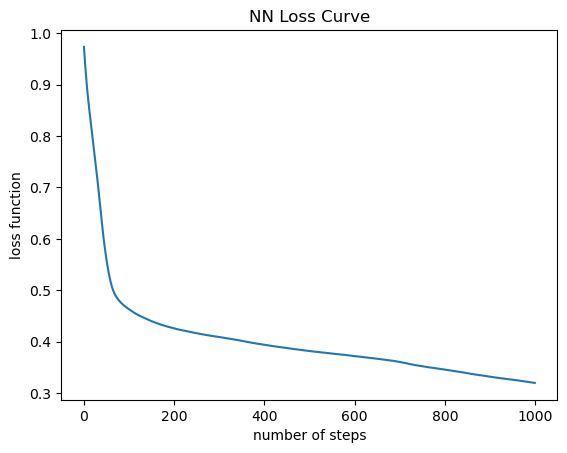

In [8]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.plot(mlp.loss_curve_)
plt.title("NN Loss Curve")
plt.xlabel("number of steps")
plt.ylabel("loss function")
plt.show()

In [9]:
mlp.intercepts_[0]

array([-0.73789541,  0.19114027, -0.48111694,  0.22361436,  0.65651171,
       -0.45474338, -0.54173307,  0.57064626,  0.54775614,  0.82921315])

In [10]:
mlp.coefs_[0]

array([[-0.73573392,  0.66128634, -0.78235156,  0.17314407,  0.56630318,
        -0.04745308,  0.1541847 , -0.84996535, -0.27455765, -0.31934634],
       [-0.16934322,  0.45350596, -0.22837276, -0.48795453, -0.20501971,
         0.93258063, -0.05062183,  0.1248382 ,  0.83068277, -0.37446488],
       [-0.26183688,  0.23212921,  0.0786913 ,  0.45696004, -0.12769152,
        -0.30026327,  0.6870468 ,  0.09727278, -0.46978622,  0.10866209],
       [-0.55121076,  0.21640212,  0.04549597, -0.18711704,  0.17419767,
        -0.34648717,  0.39765556, -0.50946379,  0.14555434,  0.16947169],
       [ 0.0894359 , -0.27538532,  0.35227155,  0.22268251, -0.37159788,
         0.3810828 , -0.1610418 ,  0.62813312, -0.51018817,  0.05251514],
       [-0.24926178, -0.0901546 ,  0.58051514,  0.04252584, -0.29214173,
        -0.97597617, -0.44887814, -0.09461574,  0.53102923,  0.04457461],
       [ 0.56841192,  0.3113257 , -0.75733597, -0.17069777, -0.24707364,
        -0.1733464 ,  0.78796791,  0.0904021 

## MLP using keras

In [11]:
from keras.models import Sequential
from keras.layers import Dense


# create keras model
model = Sequential()
model.add(Dense(12, input_dim=8, kernel_initializer='uniform', activation='relu'))
model.add(Dense(8, kernel_initializer='uniform', activation='relu'))
model.add(Dense(1, kernel_initializer='uniform', activation='sigmoid'))

print(model.summary())

/hpctmp/e1554287/conda/envs/tf312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12)             │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221 (884.00 B)

 Trainable params: 221 (884.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
from keras.utils import plot_model
#from keras.utils.vis_utils import plot_model
import IPython
plot_model(model, to_file='model.png',show_shapes=True)
IPython.display.Image("model.png")

In [13]:
# Compile model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])

# Fit the model

history=model.fit(X_train, y_train, validation_split=0.25, epochs=80, batch_size=10)
# calculate predictions

Epoch 1/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - acc: 0.6484 - loss: 0.6906 - val_acc: 0.6172 - val_loss: 0.6877
Epoch 2/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.6615 - loss: 0.6777 - val_acc: 0.6172 - val_loss: 0.6678
Epoch 3/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.6615 - loss: 0.6363 - val_acc: 0.6172 - val_loss: 0.6189
Epoch 4/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.6875 - loss: 0.5673 - val_acc: 0.6953 - val_loss: 0.5740
Epoch 5/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7604 - loss: 0.5221 - val_acc: 0.7422 - val_loss: 0.5550
Epoch 6/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7812 - loss: 0.5018 - val_acc: 0.7578 - val_loss: 0.5410
Epoch 7/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7865 - loss: 0.4893 - val_acc: 0.7656 - val_loss: 0.5289
Epoch 8/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7865 - loss: 0.4798 - val_acc: 0.7734 - val_loss: 0.5173
Epoch 9/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7865 - loss: 

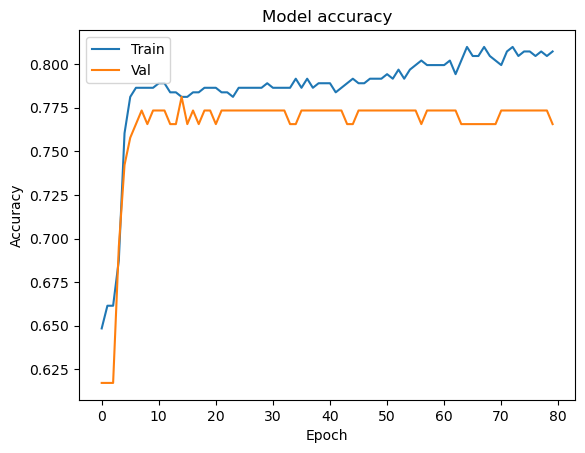

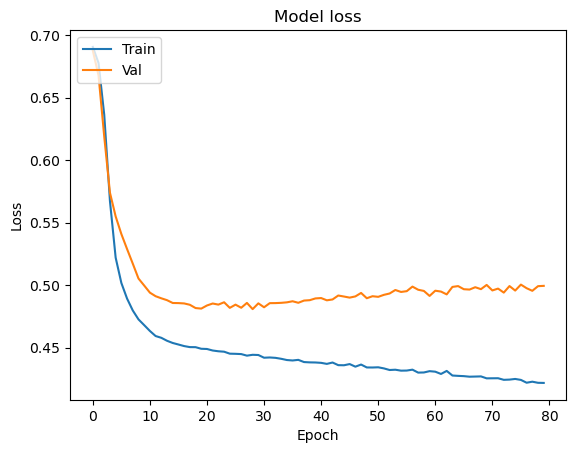

In [14]:
# Plot training & validation accuracy values
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

In [15]:
for layer in model.layers:
    weights = layer.get_weights()
    print(weights)

[array([[ 1.97866801e-02,  2.47671992e-01, -1.64346218e-01,
        -1.31372437e-01,  1.50288805e-01,  2.91840464e-01,
         1.39644429e-01,  1.97713256e-01,  1.67809129e-01,
        -1.15771003e-01, -2.56786555e-01,  5.25602810e-02],
       [-2.81380475e-01,  3.43684107e-01, -2.42406890e-01,
        -3.08688760e-01,  3.89013857e-01,  3.89015257e-01,
        -2.17974931e-01, -2.08909228e-01,  3.61506671e-01,
        -1.36054397e-01, -1.65813148e-01, -5.75790033e-02],
       [-1.18279822e-01, -2.03218058e-01,  1.32541209e-01,
         1.31619334e-01, -1.84373498e-01, -1.54518932e-02,
        -1.32200107e-01, -1.98653355e-01, -9.57508907e-02,
         2.00031951e-01,  2.35723957e-01,  1.29985437e-01],
       [-2.52546728e-01, -5.42425439e-02, -1.89869236e-02,
         3.21909077e-02, -1.62907019e-01,  9.99726951e-02,
        -1.50129065e-01, -2.04673722e-01,  1.98897403e-02,
        -7.25488439e-02,  9.27611887e-02,  1.26436561e-01],
       [ 1.44825622e-01, -1.15322471e-01, -4.730684

In [16]:
predictions = model.predict(X_test)
p_labels = [round(x[0]) for x in predictions]


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


In [17]:
p_labels

[0,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,


In [19]:
print("Accuracy", metrics.accuracy_score(y_test, p_labels))
print(confusion_matrix(y_test,p_labels))
print(classification_report(y_test,p_labels))

Accuracy 0.74609375
[[142  25]
 [ 40  49]]
              precision    recall  f1-score   support

         0.0       0.78      0.85      0.81       167
         1.0       0.66      0.55      0.60        89

    accuracy                           0.75       256
   macro avg       0.72      0.70      0.71       256
weighted avg       0.74      0.75      0.74       256



In [22]:
print('Lets vary architectures')

Lets vary architectures


In [23]:
# dense ==> fully connected layer
# input_dim ==> number of inputs in 1st layer
# activation  option: 'relu' / 'sigmoid' / 'tanh'
# kernel_initializer ==> 'uniform' / 'he_normal' / 'glorot_uniform'

model.add(Dense(16, input_dim=8, activation='relu')) # 16 neurons 1st layer
model.add(Dense(10, activation='relu')) #8 neurons 2nd layer
model.add(Dense(1, activation='sigmoid')) #1 neuron in last layer, binary classification;
# ^^ sigmoid output can be treated as probability of class "1" as it ranges from 0-1

/hpctmp/e1554287/conda/envs/tf312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.6510 - loss: 0.6894 - val_acc: 0.6172 - val_loss: 0.6818
Epoch 2/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.6615 - loss: 0.6666 - val_acc: 0.6172 - val_loss: 0.6696
Epoch 3/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.6615 - loss: 0.6519 - val_acc: 0.6172 - val_loss: 0.6602
Epoch 4/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.6615 - loss: 0.6376 - val_acc: 0.6172 - val_loss: 0.6481
Epoch 5/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.6615 - loss: 0.6196 - val_acc: 0.6172 - val_loss: 0.6292
Epoch 6/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.6615 - loss: 0.5955 - val_acc: 0.6172 - val_loss: 0.6087
Epoch 7/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7266 - loss: 0.5710 - val_acc: 0.7188 - val_loss: 0.5891
Epoch 8/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.7865 - loss: 0.5454 - val_acc: 0.7578 - val_loss: 0.5720
Epoch 9/80
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - acc: 0.8021 - loss: 

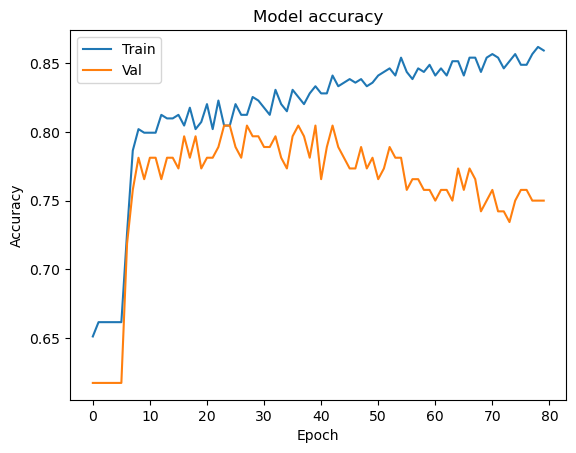

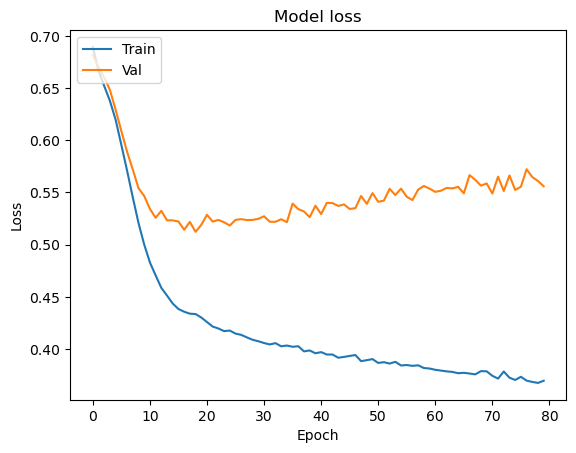

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Accuracy 0.7578125


In [24]:
# Compile model
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])

# Fit the model
history=model.fit(X_train, y_train, validation_split=0.25, epochs=80, batch_size=10)

# Plot training & validation accuracy values
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

predictions = model.predict(X_test)
p_labels = [round(x[0]) for x in predictions]
print("Accuracy", metrics.accuracy_score(y_test, p_labels))

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.initializers import HeUniform

model = Sequential()
model.add(Dense(64, input_dim=8, activation='relu', kernel_initializer=HeUniform()))
model.add(Dropout(0.3))  # Regularization to prevent overfitting
model.add(Dense(32, activation='relu', kernel_initializer=HeUniform()))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

optimizer = Adam(learning_rate=0.001)

model.compile(loss='binary_crossentropy', optimizer=optimizer, metrics=['accuracy'])

history = model.fit(X_train, y_train,
                    validation_split=0.2,
                    epochs=100,
                    batch_size=16,
                    verbose=1,
                    shuffle=True)

# Plot training & validation accuracy values
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

predictions = model.predict(X_test)
p_labels = [round(x[0]) for x in predictions]
print("Accuracy", metrics.accuracy_score(y_test, p_labels))

Epoch 1/100


/hpctmp/e1554287/conda/envs/tf312/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6161 - loss: 0.7609 - val_accuracy: 0.7184 - val_loss: 0.6248
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6919 - loss: 0.6976 - val_accuracy: 0.7282 - val_loss: 0.5482
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7359 - loss: 0.5803 - val_accuracy: 0.7282 - val_loss: 0.5270
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7408 - loss: 0.5397 - val_accuracy: 0.7476 - val_loss: 0.5305
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7531 - loss: 0.5215 - val_accuracy: 0.7670 - val_loss: 0.5089
Epoch 6/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7506 - loss: 0.5172 - val_accuracy: 0.7670 - val_loss: 0.5113
Epoch 7/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7262 - loss: 0.5474 - val_accuracy: 0.7573 - val_loss: 0.4951
Epoch 8/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7506 - loss: 0.5420 - val_accuracy: 0.7670 - val_loss: 0.4

KeyError: 'acc'

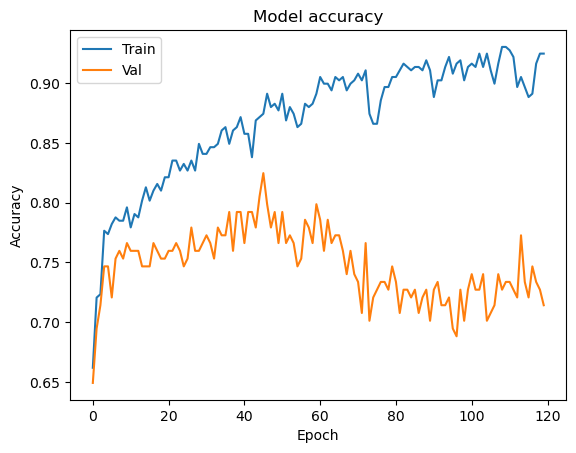

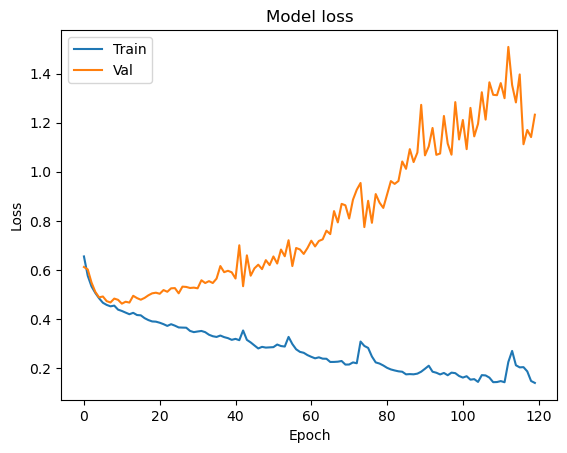

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Accuracy 0.703125


In [27]:
import tensorflow as tf
model = Sequential()
model.add(Dense(10, input_dim=8, activation='relu')) # 10 neurons 1st layer
model.add(Dense(10, activation='relu')) #10 neurons 2nd layer
model.add(Dense(5, activation='relu')) #5 neurons 3rd layer
model.add(Dense(1, activation='sigmoid'))

# Compile model
model.compile(loss='binary_crossentropy', 
              optimizer=tf.keras.optimizers.Adam(learning_rate=0.01), 
              metrics=['acc'])

# Fit the model
history=model.fit(X_train, y_train, validation_split=0.3, 
                  epochs=120, batch_size=32,
                  verbose=0)

# Plot training & validation accuracy values
plt.plot(history.history['acc'])
plt.plot(history.history['val_acc'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

predictions = model.predict(X_test)
p_labels = [round(x[0]) for x in predictions]
print("Accuracy", metrics.accuracy_score(y_test, p_labels))

In [ ]:
model = Sequential()
    model.add(Dense(12, input_dim=8, activation='relu'))
    model.add(Dense(8, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

    history = model.fit(X_train, y_train, validation_split=0.25,
                        epochs=80, batch_size=10, verbose=0)

    predictions = model.predict(X_test)
    p_labels = [round(x[0]) for x in predictions]
    acc = metrics.accuracy_score(y_test, p_labels)
    print(f"Seed {seed}: Test Accuracy = {acc:.4f}")